**Load environmental variables**: See "Getting setup" in the first modele.  `dotenv` [docs](https://pypi.org/project/python-dotenv/) will look for `../.env`. If it finds it, it will load environmental variables from there, overriding any variables in the current shell. If it is not found, variables currently in the shell are used.

**加载环境变量**：参考第一个模块中的 “环境配置” 部分。
dotenv库会自动查找上级目录下的.env文件。若找到该文件，将从中读取并加载环境变量，覆盖当前终端内的已有变量；若未找到，则沿用终端现有环境变量。

In [1]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="LangSmith now uses UUID v7", 
    category=UserWarning,
)

In [2]:
import os

from dotenv import load_dotenv

load_dotenv(os.path.join("../..", ".env"), override=True)

# 在执行新代码之前自动重新加载所有模块。用于捕获本地包的更改。
%load_ext autoreload
%autoreload 2

## 创建 Agent - 预构建

<img src="./resources/agent_header.png" width="800" style="display:block; margin-left:0;">

刚才我们介绍了基本的 agent，调用工具等等，现在我们更进一步，做一个 deep agent, 。这个 agent 可以自主式长时间运行。

在本课程中，你将搭建一个深度智能体（Deep Agent）。我们将基于 LangChain 提供的预构建智能体抽象层进行开发，这会大幅简化代码编写工作。
本节课中，你将学习预构建的 ReAct 智能体，具体内容包括:
- 什么是 ReAct 智能体
- 我们实现方案的功能，以及进一步学习的渠道
    - 为智能体配置工具（Tools）
    - 图、状态和消息
    - 在工具内部访问和修改状态
    - <span style="font-size:0.8em;">🪝</span> Hooks！和结构化响应



### 什么是 ReAct Agent 


<img src="./resources/agent.png"
     style="float:left; max-width:300px; height:auto; margin:0 1rem 0.5rem 0;">
<div style="max-width: 1250px;">
    
你将使用 LangChain 开源的 create_agent 抽象层 ([see here](https://docs.langchain.com/oss/python/langchain/agents)) abstraction. ReAct 智能体是一种人工智能智能体，它基于 ** 推理与行动（ReAct）** 框架，将思维链（CoT）推理与外部工具调用相结合。该智能体因一篇论文而广泛流行。 [ReAct: Synergizing Reasoning and Acting in Language Models](https://arxiv.org/abs/2210.03629). 



该智能体包含三大组成部分：大语言模型、可调用工具集以及指令提示词。
大语言模型以循环模式运行。每一轮迭代中，模型会查看包含可用工具列表的上下文，判断是否需要调用工具，选定工具并生成调用指令。
指令会下发至工具节点执行，执行结果反馈给大语言模型。模型依据返回结果规划下一步动作，循环往复，直至满足终止条件，通常是智能体判定无需再调用工具为止。
</div>

<div style="clear:both;"></div>


### `create_agent` 的主要功能

以下是 `create_agent` 抽象所提供的一些功能，是在第一部分 agent 上扩展的我们不会在本课程中使用所有这些功能。

- [Memory integration](../how-tos/memory/add-memory.md): 原生支持短期记忆（基于会话）和长期记忆（跨会话持久化），让聊天机器人与智能助手具备有状态交互能力。
- [Human-in-the-loop control](../concepts/human_in_the_loop.md): 执行流程可无限暂停以等待人工反馈，区别于仅支持实时交互的 WebSocket 方案。工作流程任意节点均可异步完成审核、修正与人工介入操作。`
- [Streaming support](../how-tos/streaming.md): Real-time streaming of agent state, model tokens, tool outputs, or combined streams.实时流式输出智能体状态、模型令牌、工具输出或组合流。  
- [Deployment tooling](../tutorials/langgraph-platform/local-server.md): 包含不同基础设施部署工具. [**LangGraph Platform**](https://langchain-ai.github.io/langgraph/concepts/langgraph_platform/) 支持测试、调试和部署.
  - [Studio](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/): 一款用于检查和调试工作流的可视化集成开发环境
  - [LangSmith](https://smith.langchain.com/): 一款追踪评估工具.
  - Supports multiple [deployment options](https://langchain-ai.github.io/langgraph/concepts/deployment_options.md) for production.

  

<div style="background-color: #fff3b0; padding: 10px; border-radius: 4px;">
<b>Note:</b>  
<code>create_react_agent</code>已从朗图库迁移至朗链库，并更名为<code>create_agent</code>。本课的视频与笔记文档均已同步完成更新，但其余课程仅更新了笔记文档

#### 构建带工具的 Agent

让我们从创建一个简单的计算器工具开始，先了解工具的组装方式，然后再详细地讨论。我们还是使用算数运算作为示例。

（1）创建一个计算器工具

（2）创建一个 ReAct 智能体

（3）运行智能体


In [3]:
from typing import Annotated, List, Literal, Union

from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command


@tool
def calculator(
    operation: Literal["add","subtract","multiply","divide"],
    a: Union[int, float],
    b: Union[int, float],
) -> Union[int, float]:
    """Define a two-input calculator tool that returns precise answers.

    Arg:
        operation (str): The operation to perform ('add', 'subtract', 'multiply', 'divide').
        a (float or int): The first number.
        b (float or int): The second number.
        
    Returns:
        result (float or int): the result of the operation
    Example
        Divide: result   = a / b
        Subtract: result = a - b
    """
    if operation == 'divide' and b == 0:
        return {"error": "Division by zero is not allowed."}

    # 执行计算
    if operation == 'add':
        result = a + b
    elif operation == 'subtract':
        result = a - b
    elif operation == 'multiply':
        result = a * b
    elif operation == 'divide':
        result = a / b
    else: 
        result = "unknown operation"
    return result


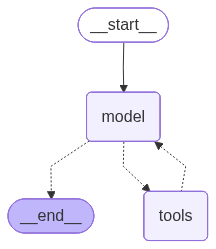

In [4]:
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain.agents import create_agent 
from utils import format_messages

# 使用 create_agent 直接创建 Agent
SYSTEM_PROMPT = """
你是一名擅长使用计算器的实用算术助手。
以纯文本形式返回所有内容，不要使用马克down数学分隔符。.
"""

model = init_chat_model(model="deepseek-chat", temperature=0.0)
tools = [calculator]

# 创建 Agent
agent = create_agent(             
    model,
    tools,
    system_prompt=SYSTEM_PROMPT,  
    #state_schema=AgentState,  # default
).with_config({"recursion_limit": 20})  #recursion_limit limits the number of steps the agent will run

# 显示 Agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [5]:
# create_react_agent 返回一个编译后的图
type(agent)

langgraph.graph.state.CompiledStateGraph

### 图、状态和消息 (Graph, State, Messages)

首先，让我们熟悉一下这些核心组件。如果你想动手搭建一个简化版本，可以参考 [Foundation: Introduction to LangGraph, Module 1, Lesson 6, Agent](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239232-lesson-6-agent)。

**定义 Agent**：当你像上面那样创建一个 Agent 时，需要准备这几样东西：模型、一个或多个工具、一段"系统"提示词，以及状态模式——默认使用的是 <a href="https://github.com/langchain-ai/langgraph/blob/e365b2b8bd695e03d758b19ff109152b2e342a87/libs/prebuilt/langgraph/prebuilt/chat_agent_executor.py#L62-L69"><code style="color:#0366d6;">AgentState</code></a>，本质上就是一个消息列表。（更多细节可以查看[官方文档](https://langchain-ai.github.io/langgraph/reference/agents/#langgraph.prebuilt.chat_agent_executor.create_react_agent)）

在底层，这其实是在定义和编译我们之前看到的 LangGraph 流程图。值得一提的是，工具节点也是一个开箱即用的组件，叫做 `ToolNode`，具体说明见[这里](https://github.com/langchain-ai/langgraph/blob/e365b2b8bd695e03d758b19ff109152b2e342a87/libs/prebuilt/langgraph/prebuilt/tool_node.py#L239-L293)。它会自动识别 LLM 消息中提到的工具并执行，然后把结果返回。

**调用 Agent**：
好了，让我们来实际运行一下这个 Agent，看看会发生什么！


In [6]:
# 示例用法
result1 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "3.1乘以4.2等于多少？",
            }
        ],
    }
)

format_messages(result1["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 3.1乘以4.2等于多少？                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 好的，我们一步一步来计算。                                                                                      │
│                                                                                                                 │
│ 首先，3.1 乘以 4.2：                                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: calculator                                                                                        │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3.1,                                                                                                     │
│   "b": 4.2                                                                                                      │
│ }                                                                                                               │
│    ID: call_00_gUTMhCti1TaRQ4THQZQg1620                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 13.020000000000001                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 3.1 乘以 4.2 等于 **13.02**。                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

**Invoking the Agent:** 
时序图能够直观展示模型被调用时的运行过程

<div style="display:none">
    the mermaid code is saved here for future
```mermaid
sequenceDiagram
    participant U as User
    participant A as LLM
    participant T as Tools
    Note over A: System message<br/>"You are a helpful assistant..."
    U->>A: Initial input,<br/>"What is 3.1 * 4.2?"
    loop while tool_calls present
        A->>T: AIMessage(id="call_123", tool_calls=[...])
        T-->>A: ToolMessage(tool_call_id="call_123", content="xx")
    end
    A->>U: Return final state
```
</div> 

<img src="./resources/agent_sequence_diagram.png"
     style="float:left; max-width:500px; height:auto; margin:0 1rem 0.5rem 0;">
<div style="max-width: 1100px;">
在本例中，用户输入内容为“3.1乘以4.2等于多少？”。该内容会同系统提示词与工具描述一并发送给大语言模型。  
<br/>
<p style="margin-bottom:0; margin-top:5px;">    大语言模型根据用户输入，判断需要调用计算器工具。它将一个 AIMessage 添加到 `messages`:</p>
<pre style="font-size:0.85em; margin-top:5px; margin-bottom:0;">
<code class="language-python">AIMessage(
    content="",
    tool_calls=[{"id": "call_123",
                 "name": "calculator",
                 "args": {"a": 3.1, "b": 4.2, "operation": "multiply"}}])</code></pre>   
</code></pre>
<br/>
<p style="margin-bottom:0;">    大算术器工具执行后，返回结果“13.02”。它将一个 ToolMessage 添加到 `messages`:</p>
<pre style="font-size:0.85em; margin-top:5px; margin-bottom:10px;">
<code class="language-python">ToolMessage(
    content="13.02",         # The result of the tool execution.
    tool_call_id="call_123")  # Matches the id from the AIMessage.tool_calls
</code></pre>
        大语言模型根据 `messages` 中的 ToolMessage，判断是否完成。如果是，它将一个 AIMessage 添加到 `messages` 给用户。

</div>

<div style="clear:both;"></div>

Let's look at a prior [trace in LangSmith](https://smith.langchain.com/public/3d2062e3-8713-4510-a797-801abe44d1f7/r). Here are some things to notice:
- In the metadata of the call to the LLM, you will see the 'calculator' tool description.
- The response from the model is a tool call with the arguments
- In the final call to the LLM, notice the matching tool_call_id's provided by the tool node.

#### 自己试试
花点时间自己试试。运行一个查询，在 LangSmith 中检查你自己的跟踪，看看它是否符合你的预期。尝试扩展计算器 - 也许添加一个平方函数。

In [7]:
# 自己试试 
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is ...?",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is ...?                                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I don't see a complete question here. It looks like you started typing "What is ...?" but didn't finish your    │
│ question.                                                                                                       │
│                                                                                                                 │
│ Could you please provide the full question you'd like me to help with? I'm here to assist with calculations and │
│ arithmetic problems!                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### 在工具内部访问和修改状态
#### 状态
状态管理是 LangGraph 一个非常实用的特性。它提供了一个带类型的数据结构，在整个图谱运行期间，各个节点都可以访问和修改这个数据，同时还能长期保存下来。利用这个功能，你可以存储数据、在节点之间共享信息、排查图谱运行中的问题，甚至可以将长时间运行的图谱回退到之前的状态。

当你为图谱定义状态时，需要指定数据类型和一个 "reducer" 函数。reducer 决定了新数据如何合并到现有状态中。这在任务被分发到多个节点并行执行、同时更新状态时特别有用。

在这个示例中，我们使用了默认的 `AgentState`，其定义可以在 [langgraph.prebuilt.chat_agent_executor](https://github.com/langchain-ai/langgraph/blob/e365b2b8bd695e03d758b19ff109152b2e342a87/libs/prebuilt/langgraph/prebuilt/chat_agent_executor.py) 中找到：


In [8]:
from IPython.display import JSON
from langchain_core.messages import messages_to_dict

JSON({"messages": messages_to_dict(result1["messages"])})

<IPython.core.display.JSON object>

#### 自定义状态
让我们扩展我们的计算器功能，使其保存所有已执行的运算记录。
这需要在状态中添加一个列表，并编写一个 ** 归约函数（reducer function）** 将运算记录添加到该列表中。
这将妥善处理列表为空或运算为空的情况


In [9]:
#from langgraph.prebuilt.chat_agent_executor import AgentState
from langchain.agents import AgentState  # 1.0 版本更新


def reduce_list(left: list | None, right: list | None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None): The first list to combine, or None.
        right (list | None): The second list to combine, or None.

    Returns:
        list: A new list containing all elements from both input lists.
               If an input is None, it's treated as an empty list.
    """
    if not left:
        left = []
    if not right:
        right = []
    return left + right

class CalcState(AgentState):
    """Graph State."""
    ops: Annotated[List[str], reduce_list]


#### 访问状态 
如今我们可以对计算器功能进行扩展，加入更新逻辑。这就暴露出一个问题：此时状态成为了计算器工具的传入参数。
<img src="./resources/state_arg_diagram.png" width="800" style="display:block; margin-left:0;">


从示意图中能够明显看出，大语言模型虽负责生成工具调用指令，但因其上下文不存在状态数据，无法构建出`state`参数。
解决办法是在大语言模型处理完成后**注入状态信息**。
<img src="./resources/inject_state_diagram.png" width="1000" style="display:block; margin-left:0;">

<div style="margin:0; padding:0">
  <p style="margin:0;">该操作通过<code>注入状态</code>注解实现，如下所示：</p>
  <pre style="font-size:0.90em; margin:0; padding-top:0;">
<code class="language-python">    @tool
    def calculator_wstate(
        operation: Literal["add","subtract","multiply","divide"],
        a: Union[int, float],
        b: Union[int, float],
        <span style="background:#fff3a3; padding:0 2px;">state: Annotated[CalcState, InjectedState],</span>  # ← not sent to LLM
        <span style="background:#fff3a3; padding:0 2px;">tool_call_id: Annotated[str, InjectedToolCallId],</span>  # ← not sent to LLM
    ) -> Union[int, float]:
</code></pre>
<p style="margin:0; padding-top:4px;">
    该操作会从提供给大语言模型的描述中剔除<code>状态</code>信息，并在<code>工具节点</code>内调用工具时重新注入该信息，同时也会纳入<code>工具调用编号</code>。相关内容将在下一小节进行说明。
  </p>
</div>

#### 更新状态
你或许还记得，工具通常会通过工具消息将观测结果返回给大语言模型，该消息存放于状态的消息字段中。若要更新状态里的其他成员，就需要拓展这套更新机制，具体可借助指令实现，如下方返回内容所示。 
```python
    return Command(
        update={
            "ops": ops,
            "messages": [
                ToolMessage(f"{result}", tool_call_id=tool_call_id)
            ]})
```
请注意，创建`工具消息`需要用到`工具调用编号`。

In [10]:
@tool
def calculator_wstate(
    operation: Literal["add","subtract","multiply","divide"],
    a: Union[int, float],
    b: Union[int, float],
    state: Annotated[CalcState, InjectedState],   # not sent to LLM
    tool_call_id: Annotated[str, InjectedToolCallId] # not sent to LLM
) -> Union[int, float]:
    """Define a two-input calculator tool.

    Arg:
        operation (str): The operation to perform ('add', 'subtract', 'multiply', 'divide').
        a (float or int): The first number.
        b (float or int): The second number.
        
    Returns:
        result (float or int): the result of the operation
    Example
        Divide: result   = a / b
        Subtract: result = a - b
    """
    if operation == 'divide' and b == 0:
        return {"error": "Division by zero is not allowed."}

    # 执行计算
    if operation == 'add':
        result = a + b
    elif operation == 'subtract':
        result = a - b
    elif operation == 'multiply':
        result = a * b
    elif operation == 'divide':
        result = a / b
    else: 
        result = "unknown operation"
    ops = [f"({operation}, {a}, {b})," ]
    return Command(
        update={
            "ops": ops,
            "messages": [
                ToolMessage(f"{result}", tool_call_id=tool_call_id)
            ],
        }
    )



In [11]:
SYSTEM_PROMPT = """
释义：你是一名擅长使用计算器的算术助手，输出内容均为纯文本格式，不使用markdown数学分隔符号。
"""

model = init_chat_model(model="deepseek-chat", temperature=0.0)
tools = [calculator_wstate]  # 新工具

# 创建 Agent
agent = create_agent(
    model,
    tools,
    system_prompt=SYSTEM_PROMPT,
    state_schema=CalcState,  # 现在定义状态模式
).with_config({"recursion_limit": 20})  #recursion_limit limits the number of steps the agent will run

In [12]:
# 示例用法
result2 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is 3.1 * 4.2?",
            }
        ],
    }
)

format_messages(result2["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is 3.1 * 4.2?                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Let me calculate that for you.                                                                                  │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3.1,                                                                                                     │
│   "b": 4.2                                                                                                      │
│ }                                                                                                               │
│    ID: call_00_kohxnPs0QYCvU2K7rVzm0957                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 13.020000000000001                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 3.1 * 4.2 = 13.02                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [13]:
# 注意 ops 字段现在在响应中
JSON(result2)

<IPython.core.display.JSON object>

让我们再试一个例子。注意，这个例子中，工具节点会并行执行这两个工具调用，。


In [14]:
# 示例用法
result3 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is 3.1 * 4.2 + 5.5 * 6.5?",
            }
        ],
    }
)

format_messages(result3["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is 3.1 * 4.2 + 5.5 * 6.5?                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Let me calculate this step by step.                                                                             │
│                                                                                                                 │
│ First, calculate 3.1 * 4.2:                                                                                     │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3.1,                                                                                                     │
│   "b": 4.2                                                                                                      │
│ }                                                                                                               │
│    ID: call_00_piUYeoVrRnoHFVrzTHNR5220                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 13.020000000000001                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Now calculate 5.5 * 6.5:                                                                                        │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 5.5,                                                                                                     │
│   "b": 6.5                                                                                                      │
│ }                                                                                                               │
│    ID: call_00_wvFFA8bSHGfCWOTM6PDh9086                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 35.75                                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Now add the two results together:                                                                               │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 13.020000000000001,                                                                                      │
│   "b": 35.75                                                                                                    │
│ }                                                                                                               │
│    ID: call_00_2SpqmuEjBksNfCuu24zl7247                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 48.77                                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ The result of 3.1 * 4.2 + 5.5 * 6.5 is **48.77**.                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [15]:
JSON(result3)

<IPython.core.display.JSON object>

In [16]:
# 示例用法 - create your own
result4 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Create an example of your own?",
            }
        ],
    }
)

format_messages(result4["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Create an example of your own?                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 好的！我来设计一个自己的计算示例。                                                                              │
│                                                                                                                 │
│ 假设我们要计算一个简单的购物总价：                                                                              │
│                                                                                                                 │
│ **问题**：小明买了 3 本书，每本 25 元，又买了 2 支笔，每支 8 元。请问一共花了多少钱？                           │
│                                                                                                                 │
│ 先算书的总价：3 × 25                                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3,                                                                                                       │
│   "b": 25                                                                                                       │
│ }                                                                                                               │
│    ID: call_00_kKG3ifX9NbtHAsV9yHRD7523                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 75                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 书的总价是 75 元。                                                                                              │
│                                                                                                                 │
│ 再算笔的总价：2 × 8                                                                                             │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 2,                                                                                                       │
│   "b": 8                                                                                                        │
│ }                                                                                                               │
│    ID: call_00_QfvOBEBLIBae69mGvJJr7033                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 16                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 笔的总价是 16 元。                                                                                              │
│                                                                                                                 │
│ 最后加起来：75 + 16                                                                                             │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 75,                                                                                                      │
│   "b": 16                                                                                                       │
│ }                                                                                                               │
│    ID: call_00_xAwsYllGBjOZotujHpzV2681                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 91                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ **答案**：小明一共花了 **91 元**。                                                                              │
│                                                                                                                 │
│ 计算过程：                                                                                                      │
│ - 书：3 本 × 25 元 = 75 元                                                                                      │
│ - 笔：2 支 × 8 元 = 16 元                                                                                       │
│ - 总计：75 元 + 16 元 = 91 元 ✅                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯